# SMA Crossover Backtest in Depth: Fees, Parameter Sweep, Overfitting Risk

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mindgaptech/algodrill-notebooks/blob/main/notebooks/sma_crossover_backtest.ipynb)

Companion notebook to [algodrill.app/code/sma-crossover-backtest](https://algodrill.app/code/sma-crossover-backtest). Extends the [first-trading-bot](https://algodrill.app/code/first-trading-bot) script with a fee-sensitivity table and a 3-combination parameter sweep on the SPY 10/50 SMA crossover -- the same dataset gives returns from +106.6% to +134.4% depending purely on which windows you pick.

**Nothing here is investment advice.** This is a backtest, not a live trading system, and it never connects to a broker. See [algodrill.app/backtesting-pitfalls](https://algodrill.app/backtesting-pitfalls) before drawing conclusions from a parameter sweep on one historical path.

## Setup

Run this cell first if you're in Colab (installs the pinned versions below into the Colab runtime). If you're running locally with the versions already installed, skip it.

In [1]:
# Colab only -- uncomment to install. Local runs should already have these
# pinned via: uv venv .venv && uv pip install -p .venv vectorbt==1.0.0 yfinance==1.4.1 pandas==2.3.3
# !pip install -q vectorbt==1.0.0 yfinance==1.4.1 pandas==2.3.3

## Base run, fee sensitivity, parameter sweep

Same SPY data and 10/50 SMA crossover as the hero script, then two additions: fee sensitivity (0 vs 5 vs 20 bps) and a 3-combination window sweep (5/20, 10/50, 20/100). The sweep's spread -- not any single row -- is the lesson.

In [2]:
"""AlgoDrill — SMA crossover backtest in depth with vectorbt.

Extends the hero script: fee sensitivity + a 3-combo parameter sweep
to illustrate why a single run proves nothing. Backtest only — no broker.

Versions: vectorbt 1.0.0 · yfinance 1.4.1 · pandas 2.3.3 (run 2026-06-05)
Install:  pip install vectorbt yfinance
"""
import vectorbt as vbt

# 1. Data — same fixed window as the hero script (reproducible)
price = vbt.YFData.download(
    "SPY", start="2015-01-01", end="2024-12-31"
).get("Close")

# 2. Base run: 10/50 SMA crossover, 5 bps fees each side
fast = vbt.MA.run(price, 10)
slow = vbt.MA.run(price, 50)
entries = fast.ma_crossed_above(slow)   # golden cross → buy
exits   = fast.ma_crossed_below(slow)   # death cross  → sell
pf = vbt.Portfolio.from_signals(
    price, entries, exits, init_cash=10_000, fees=0.0005, freq="d"
)
print("=== Base run: fast=10, slow=50, fees=5 bps ===")
print(f"Total Return  {pf.total_return():>8.1%}")
print(f"Sharpe Ratio  {pf.sharpe_ratio():>8.2f}")
print(f"Max Drawdown  {pf.max_drawdown():>8.1%}")
print(f"Trades        {pf.trades.count():>5}")
print(f"Win Rate      {pf.trades.win_rate():>8.1%}")
print()

# 3. Buy-and-hold benchmark (same period, no fees)
bh = vbt.Portfolio.from_holding(price, init_cash=10_000, fees=0.0, freq="d")
print(f"Buy & Hold:   {bh.total_return():.1%} return  (Sharpe {bh.sharpe_ratio():.2f})")
print()

# 4. Fee sensitivity — same parameters, 0 vs 5 vs 20 bps
print("=== Fee sensitivity (fast=10, slow=50) ===")
for bps in (0, 5, 20):
    p = vbt.Portfolio.from_signals(
        price, entries, exits, init_cash=10_000, fees=bps / 10_000, freq="d"
    )
    print(f"  {bps:>2} bps  Return {p.total_return():>7.1%}  Sharpe {p.sharpe_ratio():.2f}  MaxDD {p.max_drawdown():.1%}")
print()

# 5. Parameter sweep — 3 fast/slow combos to illustrate sensitivity
#    WARNING: cherry-picking the best row here is exactly how backtest bias works.
print("=== Parameter sweep (same data, different windows) ===")
combos = [(5, 20), (10, 50), (20, 100)]
for f_w, s_w in combos:
    fa = vbt.MA.run(price, f_w)
    sl = vbt.MA.run(price, s_w)
    en = fa.ma_crossed_above(sl)
    ex = fa.ma_crossed_below(sl)
    p  = vbt.Portfolio.from_signals(
        price, en, ex, init_cash=10_000, fees=0.0005, freq="d"
    )
    print(
        f"  fast={f_w:>2}/slow={s_w:>3}"
        f"  Return {p.total_return():>7.1%}"
        f"  Sharpe {p.sharpe_ratio():.2f}"
        f"  MaxDD {p.max_drawdown():.1%}"
        f"  Trades {p.trades.count():>3}"
    )


=== Base run: fast=10, slow=50, fees=5 bps ===
Total Return    106.6%


Sharpe Ratio      0.87
Max Drawdown    -15.1%
Trades           30
Win Rate         46.7%



Buy & Hold:   240.8% return  (Sharpe 0.95)

=== Fee sensitivity (fast=10, slow=50) ===
   0 bps  Return  112.8%  Sharpe 0.90  MaxDD -14.9%
   5 bps  Return  106.6%  Sharpe 0.87  MaxDD -15.1%
  20 bps  Return   89.1%  Sharpe 0.77  MaxDD -15.6%

=== Parameter sweep (same data, different windows) ===


  fast= 5/slow= 20  Return  134.4%  Sharpe 1.03  MaxDD -19.2%  Trades  67
  fast=10/slow= 50  Return  106.6%  Sharpe 0.87  MaxDD -15.1%  Trades  30
  fast=20/slow=100  Return  111.7%  Sharpe 0.81  MaxDD -22.0%  Trades  12


## Plot the three equity curves

Not in the original script (which only prints summary stats) -- overlaying the three parameter combos' equity curves shows the overfitting risk directly: the curves diverge over time even though they trade the same underlying data.

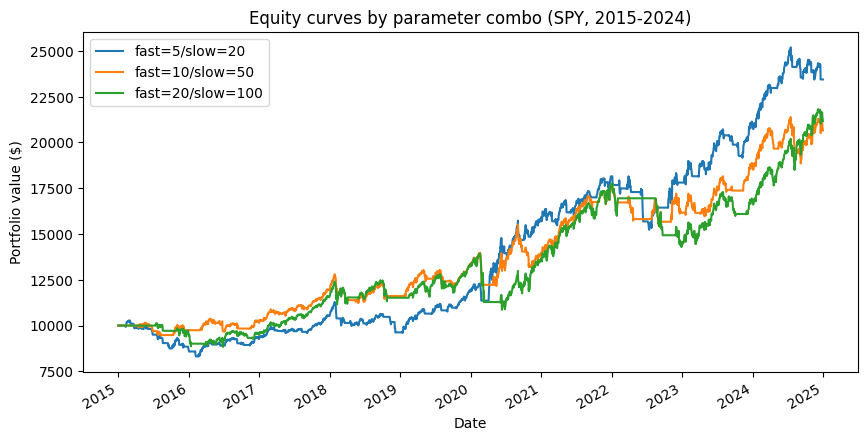

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for f_w, s_w in combos:
    fa = vbt.MA.run(price, f_w)
    sl = vbt.MA.run(price, s_w)
    en = fa.ma_crossed_above(sl)
    ex = fa.ma_crossed_below(sl)
    p = vbt.Portfolio.from_signals(
        price, en, ex, init_cash=10_000, fees=0.0005, freq="d"
    )
    p.value().plot(label=f"fast={f_w}/slow={s_w}")

plt.legend()
plt.title("Equity curves by parameter combo (SPY, 2015-2024)")
plt.ylabel("Portfolio value ($)")
plt.show()

## The overfitting risk, visualized

The three curves start identically (same $10,000, same first months of data) and diverge as each combination's signals fire at different points. The fast=5/slow=20 combination ends highest in this window -- but that is exactly the trap: it fit *this* historical path best, which says nothing about whether it has a real edge going forward. See [SMA Crossover Backtest in Depth](https://algodrill.app/code/sma-crossover-backtest) for the full fee-sensitivity and sweep tables, and [Walk-Forward Analysis](https://algodrill.app/walk-forward-analysis) for how to validate a parameter choice out-of-sample instead of picking the best in-sample row.

---
Back to [All Code Walkthroughs](https://algodrill.app/code) &middot; [algodrill-notebooks on GitHub](https://github.com/mindgaptech/algodrill-notebooks)